In [1]:
# imports
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.io
from sklearn.decomposition import PCA

In [2]:
from matplotlib.font_manager import fontManager, FontProperties

path = "Figure_data/MYRIADPRO-REGULAR.OTF"
fontManager.addfont(path)
prop = FontProperties(fname=path)

In [3]:
# load the stimulus images 
AAT_ratings = np.load('Figure_data/AAT_ratings.npy')

In [4]:
# exclude one participant with binary ratings
AAT_includes = AAT_ratings[:,0:33]
# group mean of AAT score
AATavg = np.mean(AAT_includes,axis=1)
AATstd = np.std(AAT_includes,axis=1)

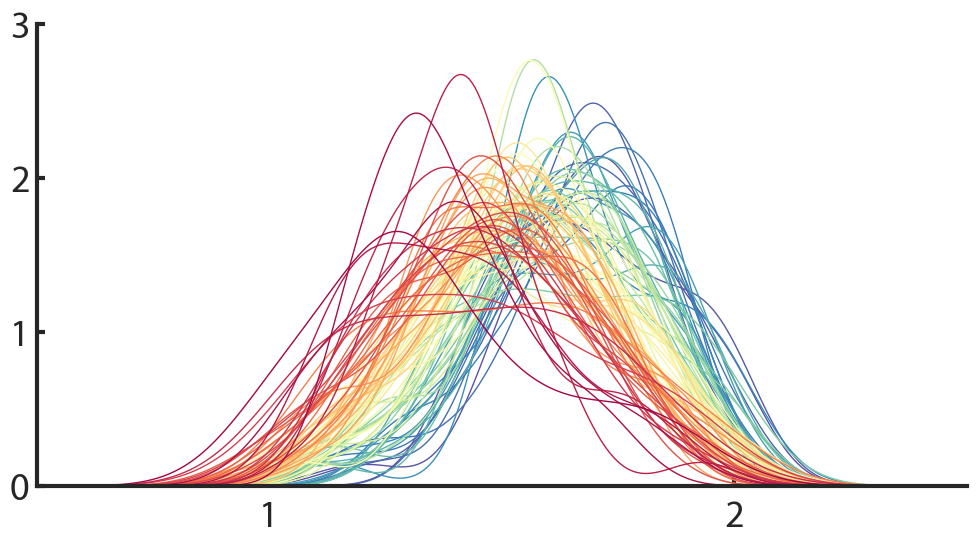

In [5]:
# individual distribution of ratinbgs
AAT_includes_sorted = AAT_includes[np.argsort(AATavg),:]
sns.set(font_scale=2.5,style="ticks",rc={'figure.figsize':(12,6)},font=prop.get_name())
#ax_dist= sns.displot(AAT_ratings[:,0:33], kind="kde", aspect=15/8)
ax_dist=sns.kdeplot(
   data=AAT_includes_sorted.T,bw_adjust=1,
   fill=True, common_norm=False, palette="Spectral",
   alpha=0, linewidth=1,
)
ax_dist.legend_.remove()
#ax_dist.set(ylabel='Density', xlabel='Aesthetic Ratings')
ax_dist.set(ylabel='', xlabel='')
ax_dist.set(ylim=(0,3), yticks=[0,1,2,3])
ax_dist.set(xlim=(0.5,2.5), xticks=[1,2])
ax_dist.tick_params(axis="y",direction="in", pad=5,width=3)
ax_dist.tick_params(axis="x",direction="in", pad=10,width=3)
ax_dist.spines['bottom'].set_linewidth(3)
ax_dist.spines['left'].set_linewidth(3)
sns.despine()

In [6]:
res = np.corrcoef(AAT_includes)
pca_res = PCA(n_components=10)
pca_res.fit(res)
AAT_pc = pca_res.transform(res)

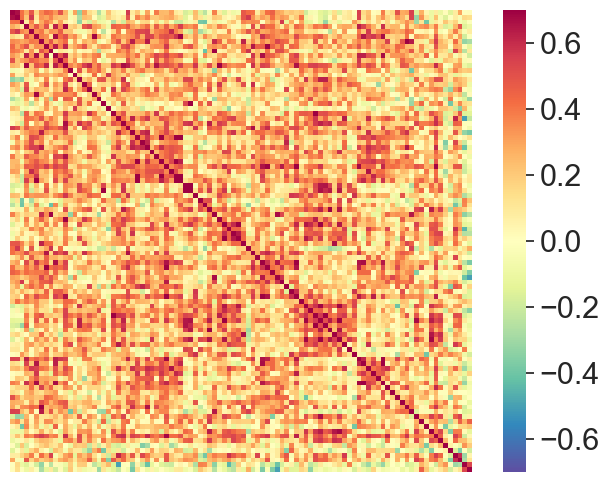

In [7]:
# plot aesthetic agreement matrix
sns.set(font_scale=2,style="white")
f,ax=plt.subplots(figsize=(8,6))
cmap = sns.color_palette("Spectral_r", as_cmap=True)
ax_mat = sns.heatmap(res,cmap=cmap,vmin=-0.7,vmax=0.7,center=0,square=True,linewidths=0.001,annot=False,xticklabels=False,yticklabels=False)

<Figure size 1200x600 with 0 Axes>

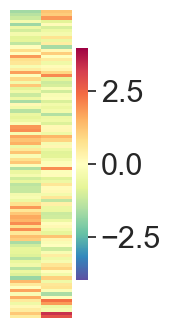

In [18]:
# plot first two PCs
sns.despine()
sns.set(font_scale=2, style="white")
f, ax = plt.subplots(figsize=(1, 4))
cmap = sns.color_palette("Spectral_r", as_cmap=True)
ax_mat = sns.heatmap(np.transpose([AAT_pc[:, 0],-AAT_pc[:, 1]]), cmap=cmap, vmin=-4, vmax=4, center=0, square=False, linewidths=0.001, annot=False,
                     xticklabels=False, yticklabels=False)

In [10]:
# load demo data for visualization
RSA_demo = scipy.io.matlab.loadmat('Figure_data//RSA_for_demoplot.mat')
RSA_target_RDM = RSA_demo['target_dsm']
RSA_temp_RDM = RSA_demo['temp_dsm']
RSA_temp_nbr = RSA_demo['temp_neigbors']

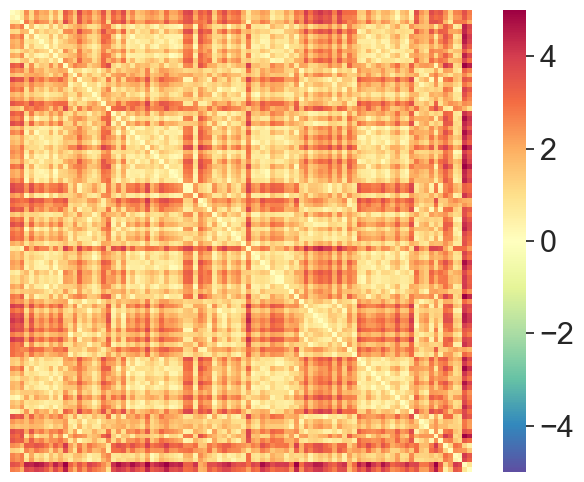

In [11]:
sns.set(font_scale=2,style="white")
f,ax=plt.subplots(figsize=(8,6))
cmap = sns.color_palette("Spectral_r", as_cmap=True)
ax_mat = sns.heatmap(RSA_target_RDM,cmap=cmap,vmin=-5,vmax=5,center=0,square=True,linewidths=0.001,annot=False,xticklabels=False,yticklabels=False)

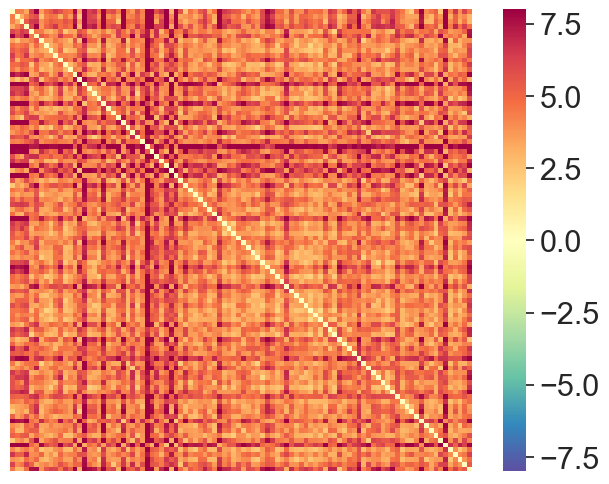

In [12]:
sns.set(font_scale=2,style="white")
f,ax=plt.subplots(figsize=(8,6))
cmap = sns.color_palette("Spectral_r", as_cmap=True)
ax_mat = sns.heatmap(RSA_temp_RDM,cmap=cmap,vmin=-8,vmax=8,center=0,square=True,linewidths=0.001,annot=False,xticklabels=False,yticklabels=False)

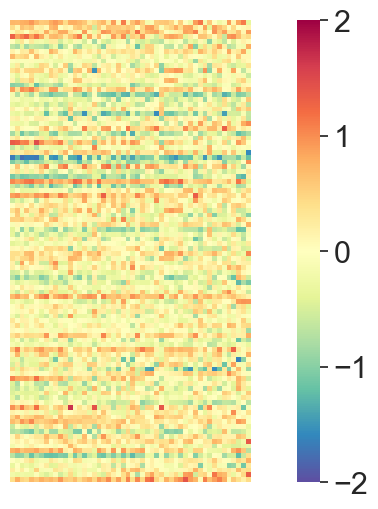

In [13]:
sns.set(font_scale=2,style="white")
f,ax=plt.subplots(figsize=(12,6))
cmap = sns.color_palette("Spectral_r", as_cmap=True)
ax_mat = sns.heatmap(RSA_temp_nbr,cmap=cmap,vmin=-2,vmax=2,center=0,square=True,linewidths=0.001,annot=False,xticklabels=False,yticklabels=False)